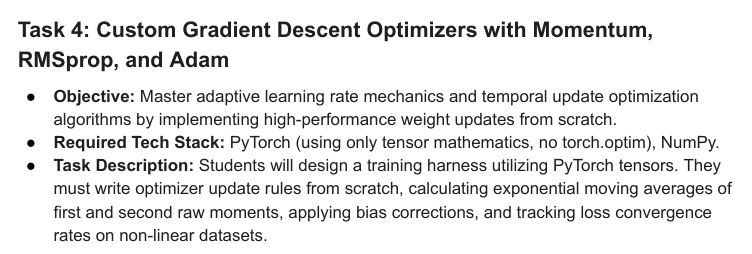

In [1]:
!pip install torch numpy matplotlib

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [3]:
torch.manual_seed(42)

X = torch.linspace(-3, 3, 200).reshape(-1, 1)

Y = X**2 + 0.3 * torch.randn_like(X)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: torch.Size([200, 1])
Y shape: torch.Size([200, 1])


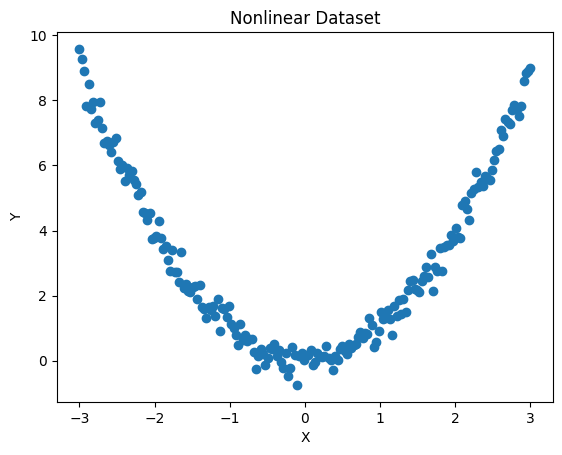

In [4]:
plt.scatter(X.numpy(), Y.numpy())

plt.xlabel("X")
plt.ylabel("Y")

plt.title("Nonlinear Dataset")

plt.show()

In [5]:
def create_model():

    return torch.nn.Sequential(
        torch.nn.Linear(1, 16),
        torch.nn.ReLU(),

        torch.nn.Linear(16, 16),
        torch.nn.ReLU(),

        torch.nn.Linear(16, 1)
    )

In [6]:
torch.optim

<module 'torch.optim' from '/usr/local/lib/python3.12/dist-packages/torch/optim/__init__.py'>

In [7]:
def update_parameters(
    model,
    updates,
    learning_rate
):

    with torch.no_grad():

        for param, update in zip(
            model.parameters(),
            updates
        ):

            param -= learning_rate * update

In [8]:
def train_momentum(
    epochs=500,
    learning_rate=0.01,
    beta=0.9
):

    model = create_model()

    velocities = []

    for param in model.parameters():

        velocities.append(
            torch.zeros_like(param)
        )

    losses = []

    for epoch in range(epochs):

        prediction = model(X)

        loss = torch.mean(
            (prediction - Y) ** 2
        )

        model.zero_grad()

        loss.backward()

        updates = []

        for i, param in enumerate(
            model.parameters()
        ):

            velocities[i] = (
                beta * velocities[i]
                + param.grad
            )

            updates.append(
                velocities[i]
            )

        update_parameters(
            model,
            updates,
            learning_rate
        )

        losses.append(
            loss.item()
        )

    return model, losses

In [9]:
momentum_model, momentum_loss = train_momentum()

print(
    "Final Momentum Loss:",
    momentum_loss[-1]
)

Final Momentum Loss: 0.08443087339401245


In [10]:
def train_rmsprop(
    epochs=500,
    learning_rate=0.01,
    beta=0.9,
    epsilon=1e-8
):

    model = create_model()

    squared_gradients = []

    for param in model.parameters():

        squared_gradients.append(
            torch.zeros_like(param)
        )

    losses = []

    for epoch in range(epochs):

        prediction = model(X)

        loss = torch.mean(
            (prediction - Y) ** 2
        )

        model.zero_grad()

        loss.backward()

        updates = []

        for i, param in enumerate(
            model.parameters()
        ):

            squared_gradients[i] = (
                beta * squared_gradients[i]
                +
                (1 - beta) * param.grad**2
            )

            update = (
                param.grad /
                (
                    torch.sqrt(
                        squared_gradients[i]
                    )
                    + epsilon
                )
            )

            updates.append(update)

        update_parameters(
            model,
            updates,
            learning_rate
        )

        losses.append(
            loss.item()
        )

    return model, losses

In [11]:
rms_model, rms_loss = train_rmsprop()

print(
    "Final RMSprop Loss:",
    rms_loss[-1]
)

Final RMSprop Loss: 0.161657452583313


In [12]:
def train_adam(
    epochs=500,
    learning_rate=0.01,
    beta1=0.9,
    beta2=0.999,
    epsilon=1e-8
):

    model = create_model()

    m = []
    v = []

    for param in model.parameters():

        m.append(
            torch.zeros_like(param)
        )

        v.append(
            torch.zeros_like(param)
        )

    losses = []

    for epoch in range(1, epochs + 1):

        prediction = model(X)

        loss = torch.mean(
            (prediction - Y) ** 2
        )

        model.zero_grad()

        loss.backward()

        updates = []

        for i, param in enumerate(
            model.parameters()
        ):

            # First moment
            m[i] = (
                beta1 * m[i]
                +
                (1 - beta1) * param.grad
            )

            # Second moment
            v[i] = (
                beta2 * v[i]
                +
                (1 - beta2) * param.grad**2
            )

            # Bias correction
            m_hat = (
                m[i]
                /
                (1 - beta1**epoch)
            )

            v_hat = (
                v[i]
                /
                (1 - beta2**epoch)
            )

            # Adam update
            update = (
                m_hat /
                (
                    torch.sqrt(v_hat)
                    + epsilon
                )
            )

            updates.append(update)

        update_parameters(
            model,
            updates,
            learning_rate
        )

        losses.append(
            loss.item()
        )

    return model, losses

In [13]:
adam_model, adam_loss = train_adam()

print(
    "Final Adam Loss:",
    adam_loss[-1]
)

Final Adam Loss: 0.08353634923696518


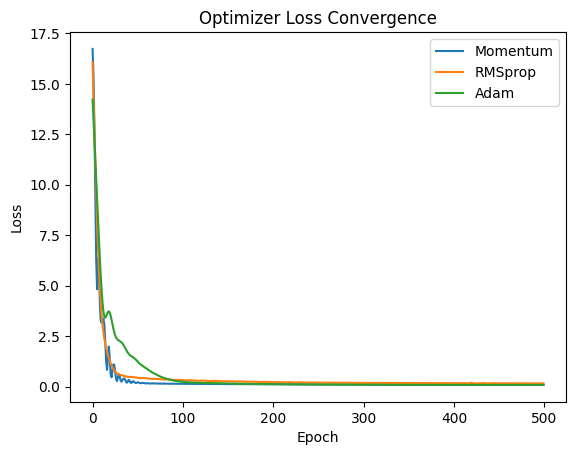

In [14]:
plt.plot(
    momentum_loss,
    label="Momentum"
)

plt.plot(
    rms_loss,
    label="RMSprop"
)

plt.plot(
    adam_loss,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Optimizer Loss Convergence"
)

plt.legend()

plt.show()

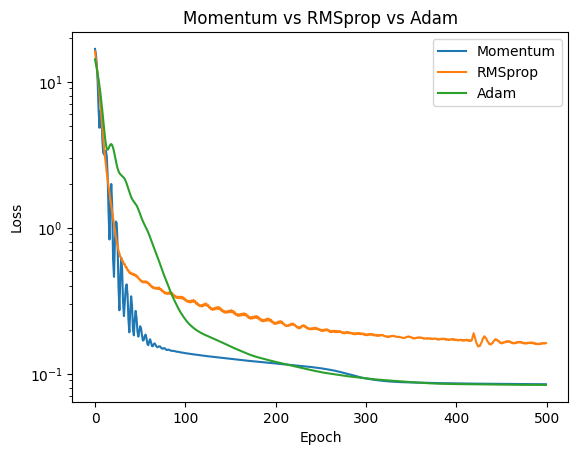

In [15]:
plt.plot(
    momentum_loss,
    label="Momentum"
)

plt.plot(
    rms_loss,
    label="RMSprop"
)

plt.plot(
    adam_loss,
    label="Adam"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Momentum vs RMSprop vs Adam"
)

plt.yscale("log")

plt.legend()

plt.show()

In [16]:
momentum_prediction = momentum_model(X)
rms_prediction = rms_model(X)
adam_prediction = adam_model(X)

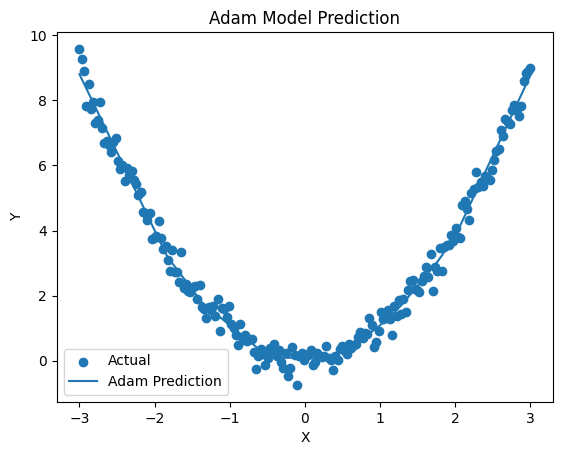

In [17]:
plt.scatter(
    X.numpy(),
    Y.numpy(),
    label="Actual"
)

plt.plot(
    X.numpy(),
    adam_prediction.detach().numpy(),
    label="Adam Prediction"
)

plt.xlabel("X")
plt.ylabel("Y")

plt.title(
    "Adam Model Prediction"
)

plt.legend()

plt.show()

In [18]:
print("Final Losses")
print("----------------------")

print(
    "Momentum:",
    momentum_loss[-1]
)

print(
    "RMSprop :",
    rms_loss[-1]
)

print(
    "Adam    :",
    adam_loss[-1]
)

Final Losses
----------------------
Momentum: 0.08443087339401245
RMSprop : 0.161657452583313
Adam    : 0.08353634923696518
